# Week 2 — Collective Communication From Scratch

**Distributed Systems for Machine Learning**

---

Every distributed training framework — PyTorch DDP, Horovod, DeepSpeed, Megatron — is ultimately a thin layer over a handful of **collective communication** primitives borrowed from MPI/NCCL:

| Primitive | Meaning |
|-----------|---------|
| **Broadcast** | one worker's data → everyone |
| **Reduce** | combine (sum/avg) everyone's data → one worker |
| **All-Reduce** | combine everyone's data → result delivered to everyone |
| **All-Gather** | concatenate everyone's shard → everyone gets the whole |
| **Reduce-Scatter** | combine, then each worker keeps one shard of the result |

**All-Reduce** is *the* operation of data-parallel training: every worker computes a local gradient, and all-reduce produces the summed gradient on every worker.

This week we implement each primitive **in pure NumPy**, count the bytes they move, and prove *why* the clever algorithms (ring, recursive halving/doubling) are **bandwidth-optimal** while the naive ones are not.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(1)
plt.rcParams["figure.figsize"] = (9,4.5); plt.rcParams["axes.grid"]=True

ALPHA = 1e-6
BETA  = 1.0/100e9   # 100 GB/s

def link_time(n_bytes): return ALPHA + BETA*n_bytes

## 1. Modeling a collective's cost

We model each algorithm by **how many communication *steps* (rounds)** it needs and **how many bytes each worker sends/receives per step**. For a message of $N$ bytes over $P$ workers we report:

- number of **rounds** (each round pays one $\alpha$),
- **bytes transferred per worker** (each byte pays $\beta$).

The α–β cost of a collective is then roughly $\#\text{rounds}\cdot\alpha + (\text{bytes per worker})\cdot\beta$. Watch how the two terms trade off: tree algorithms minimize *rounds* (good for small messages), ring algorithms minimize *bytes* (good for large messages).


## 2. Broadcast

We have buffers as NumPy arrays, one per worker, stored in a list `bufs[p]`. Broadcast copies `bufs[root]` into all of them. We implement two algorithms and *count messages explicitly*.

In [2]:
class Counter:
    def __init__(self): self.rounds=0; self.bytes_per_worker=0
    def step(self, max_bytes_any_worker):
        self.rounds += 1
        self.bytes_per_worker += max_bytes_any_worker
    def cost(self): return self.rounds*ALPHA + self.bytes_per_worker*BETA

def broadcast_linear(bufs, root, ctr):
    """root sends to each peer in turn: P-1 rounds."""
    P = len(bufs); N = bufs[root].nbytes
    for p in range(P):
        if p != root:
            bufs[p] = bufs[root].copy()
            ctr.step(N)        # root sends N bytes this 'round'
    return bufs

def broadcast_tree(bufs, root, ctr):
    """Binary-tree (recursive doubling): ceil(log2 P) rounds."""
    P = len(bufs); N = bufs[root].nbytes
    have = {root}
    while len(have) < P:
        new = set()
        for src in list(have):
            # each owner sends to one new peer this round
            for dst in range(P):
                if dst not in have and dst not in new:
                    bufs[dst] = bufs[src].copy(); new.add(dst); break
        have |= new
        ctr.step(N)            # all sends in a round happen in parallel
    return bufs

P, N = 8, 4*2**20
src = np.random.randn(N//8).astype(np.float64)  # 4 MB of float64

for fn in (broadcast_linear, broadcast_tree):
    bufs = [src.copy() if p==0 else np.zeros_like(src) for p in range(P)]
    ctr = Counter(); fn(bufs, 0, ctr)
    ok = all(np.allclose(b, src) for b in bufs)
    print(f"{fn.__name__:18s} correct={ok}  rounds={ctr.rounds:2d}  cost={ctr.cost()*1e3:.3f} ms")

broadcast_linear   correct=True  rounds= 7  cost=0.301 ms
broadcast_tree     correct=True  rounds= 3  cost=0.129 ms


The tree broadcast finishes in $\lceil\log_2 P\rceil$ rounds instead of $P-1$. For $P=8$ that's 3 vs 7 rounds — and the gap grows with cluster size. This is the *latency* advantage of trees.

## 3. All-Reduce: the naive way, the ring way

**Naive all-reduce** = reduce-to-root + broadcast-from-root. Simple, but the root is a bottleneck and total data moved is $\sim 2N(P-1)$.

**Ring all-reduce** (the Baidu/Horovod algorithm) is **bandwidth-optimal**. Idea:
1. Split each worker's vector into $P$ chunks.
2. **Reduce-scatter** phase ($P-1$ steps): chunks circulate around a ring; after this phase, worker $i$ holds the fully-summed chunk $i$.
3. **All-gather** phase ($P-1$ steps): the summed chunks circulate so everyone ends with all of them.

Each worker sends exactly $2\frac{P-1}{P}N$ bytes — **independent of $P$ in the limit**, which is provably optimal (you must at least send out your data once and receive the result once).


In [3]:
def allreduce_naive(vectors, ctr):
    """reduce to worker 0, then broadcast. vectors: list of np arrays."""
    P = len(vectors); N = vectors[0].nbytes
    total = np.zeros_like(vectors[0])
    for p in range(P):
        total += vectors[p]
        if p != 0: ctr.step(N)          # send to root
    result = [total.copy() for _ in range(P)]
    for p in range(1, P): ctr.step(N)   # broadcast back
    return result

def allreduce_ring(vectors, ctr):
    """Bandwidth-optimal ring all-reduce."""
    P = len(vectors)
    chunks = [np.array_split(v, P) for v in vectors]   # chunks[p][k]
    chunk_bytes = chunks[0][0].nbytes
    # ---- reduce-scatter ----
    for step in range(P-1):
        for p in range(P):
            send_idx = (p - step) % P
            dst = (p + 1) % P
            chunks[dst][send_idx] = chunks[dst][send_idx] + chunks[p][send_idx]
        ctr.step(chunk_bytes)   # each worker sent one chunk this step (parallel)
    # ---- all-gather ----
    for step in range(P-1):
        for p in range(P):
            send_idx = (p + 1 - step) % P
            dst = (p + 1) % P
            chunks[dst][send_idx] = chunks[p][send_idx].copy()
        ctr.step(chunk_bytes)
    return [np.concatenate(chunks[p]) for p in range(P)]

# verify both against the true sum
P = 8
vecs = [np.random.randn(1024).astype(np.float64) for _ in range(P)]
truth = sum(vecs)
for fn in (allreduce_naive, allreduce_ring):
    ctr = Counter()
    out = fn([v.copy() for v in vecs], ctr)
    ok = all(np.allclose(o, truth) for o in out)
    print(f"{fn.__name__:18s} correct={ok}  rounds={ctr.rounds:2d}  bytes/worker={ctr.bytes_per_worker}")

allreduce_naive    correct=True  rounds=14  bytes/worker=114688
allreduce_ring     correct=True  rounds=14  bytes/worker=14336


Notice the ring uses *more rounds* ($2(P-1)$) but moves a **fixed** amount of data per worker, while the naive version moves $O(NP)$ through the root. Now let's see which wins as a function of message size and cluster size.

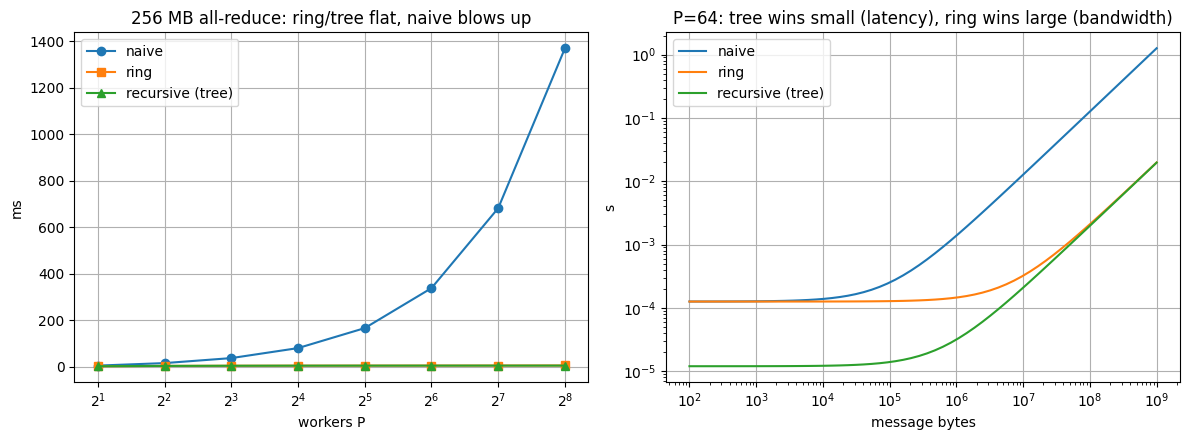

In [4]:
def cost_naive(N, P):  return 2*(P-1)*ALPHA + 2*(P-1)*N*BETA
def cost_ring(N, P):   return 2*(P-1)*ALPHA + 2*(P-1)/P*N*BETA
def cost_tree_ar(N,P): # recursive halving/doubling: 2 log2 P rounds, ~2N bytes/worker
    import math; r = 2*math.ceil(math.log2(P))
    return r*ALPHA + 2*(P-1)/P*N*BETA

Ps = [2,4,8,16,32,64,128,256]
fig, axes = plt.subplots(1,2, figsize=(12,4.5))
# vs cluster size, big message (256 MB)
N_big = 256*2**20
axes[0].plot(Ps,[cost_naive(N_big,p)*1e3 for p in Ps],"o-",label="naive")
axes[0].plot(Ps,[cost_ring(N_big,p)*1e3 for p in Ps],"s-",label="ring")
axes[0].plot(Ps,[cost_tree_ar(N_big,p)*1e3 for p in Ps],"^-",label="recursive (tree)")
axes[0].set_xscale("log",base=2); axes[0].set_xlabel("workers P"); axes[0].set_ylabel("ms")
axes[0].set_title("256 MB all-reduce: ring/tree flat, naive blows up"); axes[0].legend()
# vs message size, fixed P=64
sizes = np.logspace(2,9,60)
axes[1].loglog(sizes,[cost_naive(s,64) for s in sizes],label="naive")
axes[1].loglog(sizes,[cost_ring(s,64) for s in sizes],label="ring")
axes[1].loglog(sizes,[cost_tree_ar(s,64) for s in sizes],label="recursive (tree)")
axes[1].set_xlabel("message bytes"); axes[1].set_ylabel("s")
axes[1].set_title("P=64: tree wins small (latency), ring wins large (bandwidth)"); axes[1].legend()
plt.tight_layout(); plt.show()

**The central trade-off of collective communication:**
- For **small** messages you are latency-bound → minimize *rounds* → use **tree / recursive-doubling**.
- For **large** messages (like ML gradients) you are bandwidth-bound → minimize *bytes per worker* → use **ring**.

Real libraries (NCCL) pick the algorithm based on message size and topology automatically. You have just re-derived their decision rule.

## 4. All-Gather and Reduce-Scatter

These two are the *building blocks* of ring all-reduce, and they reappear in Week 5 as the core of **ZeRO / FSDP** parameter sharding. We implement them directly.

In [5]:
def all_gather(shards, ctr):
    """Each worker has shards[p]; everyone ends with the concatenation."""
    P = len(shards)
    full = [None]*P
    concat = np.concatenate(shards)
    for p in range(P):
        full[p] = concat.copy()
    for _ in range(P-1):
        ctr.step(shards[0].nbytes)
    return full

def reduce_scatter(vectors, ctr):
    """Sum all vectors; worker p keeps chunk p of the sum."""
    P = len(vectors)
    total = sum(vectors)
    pieces = np.array_split(total, P)
    for _ in range(P-1):
        ctr.step(pieces[0].nbytes)
    return pieces   # pieces[p] lives on worker p

P=4
shards=[np.arange(p*3,p*3+3) for p in range(P)]
ctr=Counter(); g=all_gather(shards,ctr)
print("all_gather ->", g[0], "(same on all workers)")
vecs=[np.ones(8)*p for p in range(P)]
ctr=Counter(); rs=reduce_scatter(vecs,ctr)
print("reduce_scatter total should sum 0+1+2+3=6 per element; shards:", [p.tolist() for p in rs])

all_gather -> [ 0  1  2  3  4  5  6  7  8  9 10 11] (same on all workers)
reduce_scatter total should sum 0+1+2+3=6 per element; shards: [[6.0, 6.0], [6.0, 6.0], [6.0, 6.0], [6.0, 6.0]]


## Exercises

1. **Optimality proof.** Argue informally why *any* all-reduce must send at least $\frac{(P-1)}{P}N$ bytes out of each worker. (Hint: each worker must learn the contribution of all others.) Conclude that ring all-reduce is within a factor 2 of this bound.
2. **Recursive halving/doubling.** Implement reduce-scatter via recursive halving (worker exchanges with a partner at distance $2^k$, summing half the buffer each step) and all-gather via recursive doubling. Verify it matches `np.sum` and uses $2\log_2 P$ rounds.
3. **Pipelined broadcast.** Modify `broadcast_tree` to *pipeline* a large message in chunks down the tree. Show the cost approaches $\log_2 P\cdot\alpha + N\beta$ rather than $\log_2 P\cdot(\alpha+N\beta)$.
4. **Cross-over fit.** Empirically find, for your `ALPHA`/`BETA`, the message size where ring overtakes recursive all-reduce at $P=128$. Compare to the analytic crossover.
5. **Topology.** Real clusters aren't fully connected (NVLink within a node, slower InfiniBand across nodes). Sketch how you'd run *intra-node* ring + *inter-node* ring hierarchically and why that beats a flat ring.
